<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/HW1_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
PyTorch version 2.8.0+cu126
Torchvision version 0.23.0+cu126
Numpy version 2.0.2
Pandas version 2.2.2


In [7]:
class PlayingCardDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    @property
    def classes(self):
        return self.data.classes

In [9]:
!kaggle datasets download gpiosenka/cards-image-datasetclassification --force
!unzip -o cards-image-datasetclassification.zip -d cards-image-datasetclassification


Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
 90% 348M/385M [00:00<00:00, 509MB/s]
100% 385M/385M [00:00<00:00, 545MB/s]


In [11]:
dataset = PlayingCardDataset(
    data_dir='cards-image-datasetclassification/train'
)

In [12]:
len(dataset)


7624

1


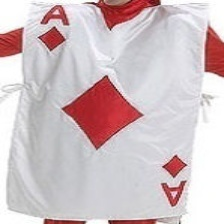

In [36]:
image, label = dataset[200]
print(label)
image

In [22]:
df.groupby('card type').size()

,0
card type,
ace,642
eight,624
five,622
four,605
jack,711
king,579
nine,580
queen,665
seven,580


In [39]:
df[df['card type'] == 'jack']

,class index,filepaths,labels,card type,data set
2333,16,train/jack of clubs/001.jpg,jack of clubs,jack,train
2334,16,train/jack of clubs/002.jpg,jack of clubs,jack,train
2335,16,train/jack of clubs/003.jpg,jack of clubs,jack,train
2336,16,train/jack of clubs/004.jpg,jack of clubs,jack,train
2337,16,train/jack of clubs/005.jpg,jack of clubs,jack,train
...,...,...,...,...,...
7985,19,valid/jack of spades/1.jpg,jack of spades,jack,valid
7986,19,valid/jack of spades/2.jpg,jack of spades,jack,valid
7987,19,valid/jack of spades/3.jpg,jack of spades,jack,valid
7988,19,valid/jack of spades/4.jpg,jack of spades,jack,valid


16


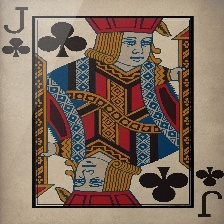

In [40]:
image, label = dataset[2333]
print(label)
image